In this notebook, we will generate synthetic stellar samples using TRILEGAL for the Kepler and K2 fields.

K2: https://archive.stsci.edu/missions-and-data/k2/campaign-fields.html#c1 and https://archive.stsci.edu/missions-and-data/k2/documents/data-release-notes

TRILEGAL: https://stev.oapd.inaf.it/cgi-bin/trilegal_1.6 

In [2]:
import os
import os.path
import numpy as np
from numpy import log, exp, pi
import pandas as pd
import scipy
import random
from scipy.stats import gaussian_kde, loguniform, gamma
from math import lgamma
from tqdm import tqdm
from ast import literal_eval
from glob import glob
from tqdm import tqdm
from itertools import zip_longest
import numpy.ma as ma # for masked arrays
from astropy.table import Table, join
import astropy.coordinates as coord
import astropy.units as u
import gala.dynamics as gd
import gala.potential as gp
from pyia import GaiaData

# these packages are for fitting with numpyro
import numpyro
from numpyro import distributions as dist, infer
import numpyro_ext
import arviz as az
import jax

# these are psps imports
from psps.transit_class import Population, Star, GeneralStar
import psps.simulate_helpers as simulate_helpers
import psps.simulate_transit as simulate_transit
import psps.utils as utils

# plotting imports
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
matplotlib.rcParams.update({'errorbar.capsize': 1})
pylab_params = {'legend.fontsize': 'large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large'}
pylab.rcParams.update(pylab_params)

import warnings
warnings.filterwarnings("ignore")

path = '/Users/chrislam/Desktop/psps/' 

# we're gonna need this for reading in the initial Berger+ 2020 data
def literal_eval_w_exceptions(x):
    try:
        return literal_eval(str(x))   
    except Exception as e:
        pass

In [3]:
def draw_asymmetrically(df, mode_name, err1_name, err2_name, drawn):
    """
    Draw stellar properties with asymmetric errors. 
    This is the generalized version of draw_star_ages(), below
    
    Inputs:
    - df: berger_kepler [Pandas DataFrame]
    - mode_name: name of mode column [string]
    - err1_name: name of err1 column [string]
    - err2_name: name of err2 column [string]
    - drawn: name of new column [string]

    Output:
    - df: berger_kepler_df, now with new column with drawn parameter, "drawn" [Pandas DataFrame]
    """

    # in case df is broken up by planet and not star
    uniques = df
    
    if drawn=='age_drawn':
        x = np.linspace(0.5, 13.5, 100)
    elif drawn=='gyro_age':
        x = np.linspace(0.5, 4., 100)
    elif drawn=='stellar_radius':
        x = np.linspace(0.5, 5., 100)
    elif drawn=='stellar_mass':
        x = np.linspace(0.5, 2.5, 100)
    elif drawn=='Teff':
        x = np.linspace(3400, 8000, 1000) # x = np.linspace(3700, 7500, 1000); Z23 did (4000, 6500, 1000); originally I did (5300, 7500), but let's just make cuts separately
    elif drawn=='stellar_feh':
        x = np.linspace(-0.5, 0.5, 100)
    elif drawn=='distance':
        x = np.linspace(0, 5000, 1000)
    elif drawn=='planet_radius':
        x = np.linspace(0.5, 10, 100)
    elif drawn=='logg':
        x = np.linspace(3., 5., 1000)  # formerly 3.6 to 4.7 over 100, but there were sampling artifacts due to low resolution and incomplete coverage

    else: 
        print("Please create a column that is either age, gyro_age, stellar_radius, stellar_mass, distance, planet_radius, stellar_feh, or stellar_teff!")

    """
    TESTING
    print("x: ", x)
    pdf = make_pdf_rows(x, mode, err1, err2)
    pdf = pdf/np.sum(pdf)
    draw = np.around(np.random.choice(x, p=pdf), 2)
    print("draw: ", draw)
    """

    if drawn=='planet_radius':
        df_or_uniques = df
    else:
        df_or_uniques = uniques

    draws = np.ones(len(df_or_uniques))
    for i in range(len(df_or_uniques)):
        mode = df_or_uniques.iloc[i][mode_name]
        err1 = df_or_uniques.iloc[i][err1_name]
        err2 = np.abs(df_or_uniques.iloc[i][err2_name])
        
        #"""
        # symmetric uncertainties
        if err1==err2:
            if drawn!='stellar_feh':
                draw = 0
                while draw <= 0: # make sure the draw is positive
                    draw = np.random.normal(mode, err1) # I used to round this to two decimal places but I don't know why I did this.
            elif drawn=='stellar_feh':
                draw = np.random.normal(mode, err1)

        # asymmetric uncertainties
        elif err1!=err2:
            try:
                pdf = make_pdf_rows(x, mode, err1, err2)
                pdf = pdf/np.sum(pdf)
            except Exception as e:
                print(e)
                print(x, mode, err1, err2)

            try:
                if drawn!='stellar_feh':
                    draw = 0
                    while draw <= 0: # make sure the draw is positive
                        draw = np.random.choice(x, p=pdf)
                elif drawn=='stellar_feh':
                    draw = np.random.choice(x, p=pdf)
            except Exception as e:
                #print("EXCEPTION: ", i, pdf, mode, err1, err2)
                #print(e)
                continue
        #"""
        #if draw==1.:
        #    print(draw, mode, err1, err2)
        
        """
        ### make all draws the same way, symmetric or asymmetric
        pdf = make_pdf_rows(x, mode, err1, err2)
        pdf = pdf/np.sum(pdf)

        try:
            draw = 0
            while draw <= 0: # make sure the draw is positive
                draw = np.around(np.random.choice(x, p=pdf), 2)
        except Exception as e:
            print("EXCEPTION: ", i, pdf, mode, err1, err2)
            print(e)
            break
        """

        #print(mode, err1, err2, draw)
        draws[i] = draw

    #print(len(df), len(draws), len(uniques))
    df_or_uniques[drawn] = draws

    # break back out into planet rows and forward fill across systems
    #df = uniques.merge(df, how='right')
    #df[drawn] = df[drawn].fillna(method='ffill')
    
    return df_or_uniques

### adapted from The Cannon project with Aida
def tighter_cull(comparison_df, comparison_teff, comparison_logg):

    comparison_df = comparison_df.loc[((comparison_logg<4.4) & (comparison_teff<6300))]
    comparison_df = comparison_df.loc[((comparison_logg>3.4) & (comparison_teff>5300))]

    return comparison_df

def make_pdf_rows(x, mode, err1, err2):
    """
    Row-wise likelihood of asymmetric uncertainty, using Eqn 6 from https://iopscience.iop.org/article/10.3847/1538-3881/abd93f
    Less efficient, but row-wise in order to troubleshoot. 
    Takes in scalar values for mode, err1, and err2, not arrays.

    Input:
    - x: np.linspace(0.5, 10, 100); just something to undergird the PDF and represent stellar ages
    - mode: mean age; peak of asymmetric PDF
    - err1: + uncertainty
    - err2: - uncertainty (note: must be positive)

    Output:
    - pdf: asymmetric PDF

    """
    
    factor1 = 1/np.sqrt(2*np.pi*err1**2) 
    beta = err1/err2
    gamma = (err1 - np.abs(err2))/(err1 * np.abs(err2))
    
    factor2_arg_a = np.log(1+gamma*(x - mode))
    factor2_arg_b = np.log(beta)
    factor2_arg = factor2_arg_a/factor2_arg_b
    factor2 = np.exp(-0.5*(factor2_arg)**2)

    out = factor1 * factor2
    out[~np.isfinite(out)] = 0.0
    
    return out


In [4]:
def kepmag_to_cdpp_vectorized(data1, data2):

    """
    Use Kepler mag vs CDPP (6 hr) relation from Berger Kepler-Gaia crossmatch to infer CDPP given simulated kepmag from TRILEGAL, etc
    Fold in Teff and galactic height, since these bear indirectly on noise properties and directly on experimental dependent variables
    Inputs:
    - data1: reference DataFrame, with Kepler mag and CDPP
    - data2: target DataFrame from which to sample

    Output:
    #- cdpps: new array of CDPPs
    - new_data2: this operation culls records that have NaN heights, etc. So let's use this opportunity to cull the entire DF, rather than output a column of different length from the original
    """

    cols_to_match = ['mag_bins', 'teff_bins', 'logg_bins']
    logg_bins = np.linspace(3.0, 4.6, 5) 
    teff_bins = np.linspace(5300, 7500, 50) # (5300, 7500, 50) or (4000, 6500, 50)
    mag_bins = np.linspace(8, 16, 5)
    age_bins = np.linspace(0, 14, 10) # (0, 14, 10) or (0, 8, 10)
    stellar_radius_bins = np.linspace(1, 3.5, 5)
    cdpp_bins = np.linspace(0, 1000, 10) # (0, 100, 10)
    height_bins = np.logspace(2,3,6)
    
    # reference DataFrame
    data1['mag_bins'] = pd.cut(data1['kepmag'], bins=mag_bins, include_lowest=True)
    data1['logg_bins'] = pd.cut(data1['iso_logg'], bins=logg_bins, include_lowest=True)
    data1['teff_bins'] = pd.cut(data1['iso_teff'], bins=teff_bins, include_lowest=True)
    #data1['stellar_radius_bins'] = pd.cut(data1['iso_rad'], bins=stellar_radius_bins, include_lowest=True)
    #data1['cdpp_bins'] = pd.cut(data1['rrmscdpp06p0'], bins=cdpp_bins, include_lowest=True)
    #data1['height_bins'] = pd.cut(data1['height'], bins=height_bins, include_lowest=True)
    #data1['age_bins'] = pd.cut(data1['age'], bins=age_bins, include_lowest=True)

    data1_cdpp_mean = data1.groupby(cols_to_match)['rrmscdpp06p0'].mean().reset_index()
    data1_cdpp_mean = data1_cdpp_mean.pivot(index='mag_bins', columns=cols_to_match[1:])

    data1_cdpp_std = data1.groupby(cols_to_match)['rrmscdpp06p0'].std().reset_index()
    data1_cdpp_std = data1_cdpp_std.pivot(index='mag_bins', columns=cols_to_match[1:])

    # unstack pivot tables
    data1_unstacked_mean = data1_cdpp_mean.unstack().reset_index()
    data1_unstacked_mean = data1_unstacked_mean[['mag_bins', 'teff_bins', 'logg_bins', 0]]
    data1_unstacked_mean.columns = ['mag_bins', 'teff_bins', 'logg_bins','cdpp_mean']
    data1_unstacked_mean.dropna(subset=['cdpp_mean'], inplace=True)
    #print(data1_unstacked_mean)

    data1_unstacked_std = data1_cdpp_std.unstack().reset_index()
    data1_unstacked_std = data1_unstacked_std[['mag_bins', 'teff_bins', 'logg_bins', 0]]
    data1_unstacked_std.columns = ['mag_bins', 'teff_bins', 'logg_bins','cdpp_std']
    data1_unstacked_std.dropna(subset=['cdpp_std'], inplace=True)
    #print(data1_unstacked_std)

    # target DataFrame from which to sample
    data2['mag_bins'] = pd.cut(data2['Kepler'], bins=mag_bins, include_lowest=True)
    data2['logg_bins'] = pd.cut(data2['logg'], bins=logg_bins, include_lowest=True)
    data2['teff_bins'] = pd.cut(data2['Teff'], bins=teff_bins, include_lowest=True)
    #data2['stellar_radius_bins'] = pd.cut(data2['stellar_radius'], bins=stellar_radius_bins, include_lowest=True)
    #data2['cdpp_bins'] = pd.cut(data2['cdpp'], bins=cdpp_bins, include_lowest=True)
    #data2['height_bins'] = pd.cut(data2['height'], bins=height_bins, include_lowest=True)
    #data2['age_bins'] = pd.cut(data2['age'], bins=age_bins, include_lowest=True)
    #print(data2)

    # merge the DataFrames on the multiple columns
    new_data2 = pd.merge(data2, data1_unstacked_mean, on=cols_to_match, how='inner')
    new_data2.dropna(subset=['cdpp_mean'], inplace=True)

    new_data2 = pd.merge(new_data2, data1_unstacked_std, on=cols_to_match, how='inner')
    new_data2.dropna(subset=['cdpp_std'], inplace=True)
    #print(new_data2)

    # sample from target
    new_data2['cdpp'] = np.random.normal(new_data2['cdpp_mean'], new_data2['cdpp_std'])

    return new_data2

In [5]:
from astropy.coordinates import SkyCoord, Galactic

def convert_ra_dec_to_b(ra, dec):
	# Create a SkyCoord object in the ICRS (equatorial) frame
	# ICRS is the standard J2000 equatorial system assumed by default
	c_icrs = SkyCoord(ra=ra * u.degree, dec=dec * u.degree, frame='icrs')

	# Transform the coordinates to the Galactic frame
	c_galactic = c_icrs.transform_to(Galactic())
	# or use the shorthand attribute access:
	# c_galactic = c_icrs.galactic

	# The Galactic latitude 'b' is the angle from the Galactic midplane (b=0)
	b = c_galactic.b * u.degree
	
	return np.abs(b.value)

def ra_dec_to_b_l(ra, dec):
	c_icrs = SkyCoord(ra=ra, dec=dec, frame='icrs', unit='deg')

	# Transform the coordinates to the Galactic frame
	c_galactic = c_icrs.transform_to(Galactic())

	# The Galactic latitude 'b' is the angle from the Galactic midplane (b=0)
	b = c_galactic.b 
	l = c_galactic.l 

	return b, l

def degrees_to_radians(deg):
    return deg*np.pi/180

def dist_k2_to_height(d, b):
    """
    K2 fields have variable inclinations, so we need a second parameter, b, to do trigonometry.

    Inputs:
    - d: distance, in pc
    - b: inclination from Galactic midplane, in deg

    Output:
    - h: height off the Galactic midplane, in pc
    """

    incl = degrees_to_radians(b)
    h = d * np.sin(incl)

    return h

# K2 campaign pointings, from https://archive.stsci.edu/missions-and-data/k2/campaign-fields
ras = [173.939610, 246.1264, 336.66534641439, 59.0759116, 130.1576478, 204.8650344, 287.82850661, 16.3379975, 270.3544823, 186.7794430,
	   260.3880064, 351.6588124, 72.7971166, 160.6824762, 233.6175730, 133.7099689, 202.5496152, 
	   130.1610170, 347.2590265]
decs = [1.4172989, -22.4473, -11.096663792177, 18.6605794, 16.8296140, -11.2953585, -23.36001815, 5.2623459, -21.7798098, -4.0271572,
		-23.9759578, -5.1023328, 20.7870759, 6.8509316, -20.0792397, 18.5253931, -7.7210759, 
		16.8278629, -4.2027029]
campaigns = np.arange(19)+1
highs = [1, 3, 6, 8, 10, 12, 14, 17, 19]
lows = [2, 4, 5, 7, 9, 11, 13, 15, 16, 18]
k2_pointings = dict({'campaign': campaigns, 'ra': ras, 'dec': decs})
print(k2_pointings)

bs = []
for i in range(19):
    bs.append(convert_ra_dec_to_b(ras[i], decs[i]))

k2_pointings = dict({'campaign': campaigns, 'ra': ras, 'dec': decs, 'b': bs})
print(k2_pointings)

{'campaign': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]), 'ra': [173.93961, 246.1264, 336.66534641439, 59.0759116, 130.1576478, 204.8650344, 287.82850661, 16.3379975, 270.3544823, 186.779443, 260.3880064, 351.6588124, 72.7971166, 160.6824762, 233.617573, 133.7099689, 202.5496152, 130.161017, 347.2590265], 'dec': [1.4172989, -22.4473, -11.096663792177, 18.6605794, 16.829614, -11.2953585, -23.36001815, 5.2623459, -21.7798098, -4.0271572, -23.9759578, -5.1023328, 20.7870759, 6.8509316, -20.0792397, 18.5253931, -7.7210759, 16.8278629, -4.2027029]}
{'campaign': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19]), 'ra': [173.93961, 246.1264, 336.66534641439, 59.0759116, 130.1576478, 204.8650344, 287.82850661, 16.3379975, 270.3544823, 186.779443, 260.3880064, 351.6588124, 72.7971166, 160.6824762, 233.617573, 133.7099689, 202.5496152, 130.161017, 347.2590265], 'dec': [1.4172989, -22.4473, -11.096663792177, 18

In [6]:
# read in real Kepler+K2 sample
hu25_b20_kepler_b25_k2 = pd.read_csv(path+'data/joint/hu25_b20_kepler_b25_k2.csv')
hu25_b20_kepler_b25_k2.columns

Index(['Kepler_ID', 'Teff', 'e_Teff', 'logg', 'e_logg', 'Lum', 'e_Lum',
       '[Fe/H]', 'e_[Fe/H]', 'Rad', 'e_Rad', 'Mass', 'e_Mass', 'CDPP75',
       'CDPP6', 'KIC', 'iso_teff', 'iso_logg', 'iso_lum', 'iso_age',
       'iso_age_err1', 'iso_age_err2', 'iso_feh', 'kepid', 'source_id', 'ra',
       'dec', 'parallax', 'parallax_error', 'pmra', 'pmra_error', 'pmdec',
       'pmdec_error', 'radial_velocity', 'radial_velocity_error', 'height',
       'EPIC_ID', 'GaiaDR3', 'Campaign', 'CDPP8', 'EPIC', 'L_star', 'Age',
       'E_Age', 'e_Age', 'feh', 'SOURCE_ID', 'ra_error', 'dec_error', 'age',
       'age_err1', 'age_err2', 'source_id_dr3'],
      dtype='object')

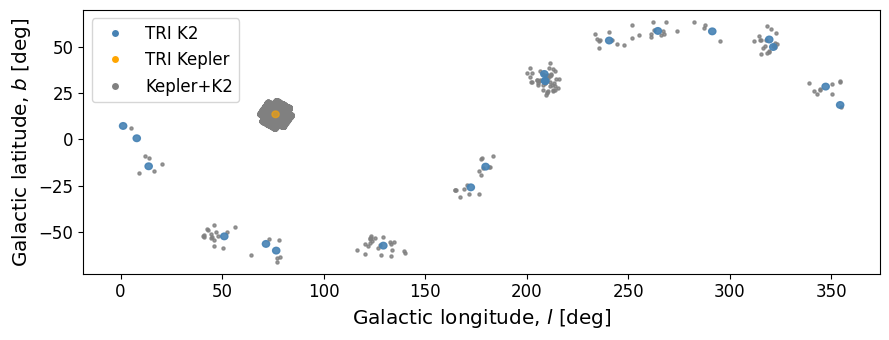

In [7]:
from matplotlib.lines import Line2D

# TRI
tri_k2_bs, tri_k2_ls = ra_dec_to_b_l(ras, decs)

fig, ax = plt.subplots(figsize=(9, 3.5))
for i in range(19):
    center = (tri_k2_ls[i].value, tri_k2_bs[i].value)
    
	# draw circle of radius sqrt(10), since the TRILEGAL queries have a window of 10 sq deg
    if i==0:
        circle = plt.Circle(center, np.sqrt(10/np.pi), alpha=0.9, color='steelblue', zorder=100, label='TRI K2')
    else:
        circle = plt.Circle(center, np.sqrt(10/np.pi), alpha=0.9, color='steelblue', zorder=100)

	# Add the circle to the axes
    ax.add_patch(circle)

# big faint circle for TRI Kepler
circle = plt.Circle((76.32, 13.5), np.sqrt(10/np.pi), alpha=0.6, color='orange', zorder=99, label='TRI Kepler')
ax.add_patch(circle)

# B23
k2_bs, k2_ls = ra_dec_to_b_l(hu25_b20_kepler_b25_k2['ra'], hu25_b20_kepler_b25_k2['dec'])

plt.scatter(k2_ls, k2_bs, label='Kepler+K2', s=5, alpha=0.8, color='gray')

obj1 = Line2D([], [], color="white", marker='o', markerfacecolor="steelblue")
obj2 = Line2D([], [], color="white", marker='o', markerfacecolor="orange")
obj3 = Line2D([], [], color="white", marker='o', markerfacecolor="gray")
plt.legend((obj1, obj2, obj3), ('TRI K2', 'TRI Kepler', 'Kepler+K2'))

plt.xlabel(r'Galactic longitude, $l$ [deg]')
plt.ylabel(r'Galactic latitude, $b$ [deg]')
plt.tight_layout()
plt.savefig(path+'plots/pointings.png')
plt.show()


At some point we're going to need to make cuts to conform with our sample's Kepmag distribution. So we need to cross-match our sample with the Bedell Gaia-Kepler cross-match to get Kepmag information. 

B23 didn't have kepmag. So I went to Exoplanet Archive's Table Access Protocol (TAP; https://exoplanetarchive.ipac.caltech.edu/docs/program_interfaces.html#k2) and queried all K2 targets there. Don't say I didn't do nothin

In [8]:
bedell = Table.read(path+'data/kepler_dr3_good.fits')
bedell_df = bedell.to_pandas()

k2candidates = pd.read_csv(path+'data/k2/k2candidates.csv', sep=',')

In [9]:
k2candidates.columns

Index(['epic_number', 'tm_name', 'k2_campaign_str', 'k2_type', 'rastr',
       'decstr', 'k2_propid', 'k2_dist', 'k2_disterr1', 'k2_disterr2',
       'k2_teff', 'k2_tefferr1', 'k2_tefferr2', 'k2_rad', 'k2_raderr1',
       'k2_raderr2', 'k2_mass', 'k2_masserr1', 'k2_masserr2', 'k2_kepmag',
       'k2_kepmagerr', 'k2_kepmagflag', 'k2_vjmag', 'k2_vjmagerr', 'k2_kmag',
       'k2_kmagerr'],
      dtype='object')

       Kepler_ID  Teff  e_Teff   logg  e_logg       Lum     e_Lum  [Fe/H]  \
0      7015160.0  5167     151  4.468   0.069  0.505556  0.043132   0.133   
1      7262873.0  5694     167  4.231   0.069  1.682723  0.124291   0.054   
2      6184474.0  5310     156  4.402   0.083  0.702968  0.054962   0.160   
3      6668281.0  5772     169  4.401   0.070  1.102606  0.083086   0.089   
4      9516660.0  5517     162  4.363   0.076  0.978101  0.090228   0.151   
...          ...   ...     ...    ...     ...       ...       ...     ...   
25088        NaN  4987     146  4.463   0.061  0.399850  0.030812   0.150   
25089        NaN  5726     168  4.462   0.066  0.847420  0.066735  -0.075   
25090        NaN  5988     175  4.382   0.075  1.422034  0.120451  -0.238   
25091        NaN  5567     163  4.422   0.067  0.811818  0.059661   0.002   
25092        NaN  5792     170  4.414   0.080  1.020128  0.084903  -0.426   

       e_[Fe/H]    Rad  ...  dec_error    age  age_err1  age_err2  \
0     

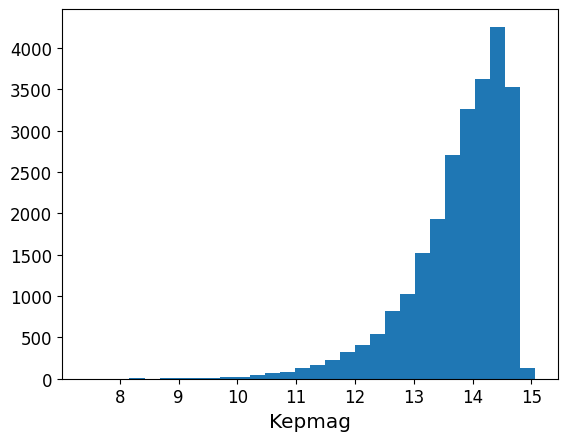

In [10]:
hu25_b20_kepler_b25_k2_kepmag_kepler = pd.merge(hu25_b20_kepler_b25_k2, bedell_df[['kepid', 'kepmag']], left_on='Kepler_ID', right_on='kepid') 
#print(hu25_b20_kepler_b25_k2_kepmag)
hu25_b20_kepler_b25_k2_kepmag_k2 = pd.merge(hu25_b20_kepler_b25_k2, k2candidates[['epic_number', 'k2_kepmag']], left_on='EPIC_ID', right_on='epic_number') 
hu25_b20_kepler_b25_k2_kepmag = pd.concat([hu25_b20_kepler_b25_k2_kepmag_kepler, hu25_b20_kepler_b25_k2_kepmag_k2], ignore_index=True)
print(hu25_b20_kepler_b25_k2_kepmag)

plt.hist(hu25_b20_kepler_b25_k2_kepmag['kepmag'], bins=30)
plt.xlabel('Kepmag')
plt.show()


Kepler

In [11]:
hu25_b20_kepler_b25_k2_kepmag.columns

Index(['Kepler_ID', 'Teff', 'e_Teff', 'logg', 'e_logg', 'Lum', 'e_Lum',
       '[Fe/H]', 'e_[Fe/H]', 'Rad', 'e_Rad', 'Mass', 'e_Mass', 'CDPP75',
       'CDPP6', 'KIC', 'iso_teff', 'iso_logg', 'iso_lum', 'iso_age',
       'iso_age_err1', 'iso_age_err2', 'iso_feh', 'kepid_x', 'source_id', 'ra',
       'dec', 'parallax', 'parallax_error', 'pmra', 'pmra_error', 'pmdec',
       'pmdec_error', 'radial_velocity', 'radial_velocity_error', 'height',
       'EPIC_ID', 'GaiaDR3', 'Campaign', 'CDPP8', 'EPIC', 'L_star', 'Age',
       'E_Age', 'e_Age', 'feh', 'SOURCE_ID', 'ra_error', 'dec_error', 'age',
       'age_err1', 'age_err2', 'source_id_dr3', 'kepid_y', 'kepmag', 'kepid',
       'epic_number', 'k2_kepmag'],
      dtype='object')

In [12]:
stem = 'data/kepler/trilegal/' 
filenames = os.listdir(path+stem)
filenames = [item for item in filenames if '.txt' in item] # omit directory name "luke"

tri_kepler = pd.DataFrame()
for i in range(len(filenames)):

	temp_kepler = pd.read_csv(path+stem+filenames[i], sep='\s+')
	temp_kepler.dropna(subset=['logAge','m2/m1'], inplace=True)

	# remove end lines from TRILEGAL, if applicable
	try:
		temp_kepler = temp_kepler[~temp_kepler['logAge'].str.contains('normally', na=False)]
	except:
		pass

	# add height column, introducing a spread of 0.05 dex based on TRILEGAL distance modulus bin size
	temp_kepler['distance'] = simulate_helpers.distance_modulus_to_distance(temp_kepler['m-M0'], perturb=True)
	temp_kepler['height'] = simulate_helpers.dist_kepler_to_height(temp_kepler['distance'])

	tri_kepler = pd.concat([tri_kepler, temp_kepler])

print("initial TRI: ", len(tri_kepler))

# remove binaries
tri_kepler = tri_kepler[tri_kepler['m2/m1']==0]
print("cut binaries: ", len(tri_kepler))

# unlog Teff. keep FGK dwarfs below Kraft break only
tri_kepler['Teff'] = 10**tri_kepler['logTe'].astype(float)
#tri_kepler = tri_kepler.loc[(tri_kepler['Teff'] <= 6500) & (tri_kepler['Teff'] >= 4000)] 
tri_kepler = tri_kepler.loc[(tri_kepler['Teff'] <= np.max(hu25_b20_kepler_b25_k2_kepmag['Teff'])) & (tri_kepler['Teff'] >= np.min(hu25_b20_kepler_b25_k2_kepmag['Teff']))] # match B20
print("Teff cut: ", len(tri_kepler))
print("max Teff: ", np.max(tri_kepler['Teff']))
print("min Teff: ", np.min(tri_kepler['Teff']))

# calculate stellar radius
tri_kepler['stellar_radius'] = simulate_helpers.stellar_radius_stefan_boltzmann(10**tri_kepler['logTe'], 10**tri_kepler['logL'])

# remove giant based on Z23 prescription, which uses Huber+16 prescription (see kepler_k2.ipynb, when I did it to the real sample)
#tri_kepler['logR'] = np.log10(tri_kepler['stellar_radius'])
#tri_kepler['is_giant'] = np.where(tri_kepler['logR'] >= 0.00035*(tri_kepler['Teff'] - 4500) + 0.15, True, False)
#tri_kepler = tri_kepler.loc[tri_kepler['is_giant'] == False]
logg_threshold_huber_2016 = np.arctan((6300 - tri_kepler['Teff'])/67.172)/4.671 + 3.876
tri_kepler = tri_kepler.loc[tri_kepler['logg'] >= logg_threshold_huber_2016]
print("cut giants via logg: ", len(tri_kepler))
print("max logg: ", np.max(tri_kepler['logg']))
print("min logg: ", np.min(tri_kepler['logg']))

# remove poofy stars, same as B20
#tri_kepler = tri_kepler.loc[(tri_kepler['logg']<4.7) & (tri_kepler['logg']>3.6)]
#tri_kepler = tri_kepler.loc[(tri_kepler['logg']<4.7) & (tri_kepler['logg']>4.)]
#print("logg cut: ", len(tri_kepler))

# TRILEGAL logAge bin size is 0.02, so let's introduce a spread of that size; note from Luke Bouma (https://github.com/lgbouma/gyrojo/blob/main/gyrojo/trilegal.py#L92-L108)
eps = np.random.normal(loc=0, scale=0.02, size=len(tri_kepler))
tri_kepler['logAge'] = tri_kepler['logAge'].astype(float)
tri_kepler['logAge'] += eps
tri_kepler['age'] = 10**tri_kepler['logAge'].astype(float) / 1e9

# remove PMS stars
tri_kepler = tri_kepler.loc[tri_kepler['age']>0.5]

# get rid of low metallicity stars because their Teff-logg relation is different
#tri_kepler = tri_kepler.loc[tri_kepler['[M/H]'].astype(float)>=-0.6] # this is different from Fe/H cut for B20, but we only have apples v oranges
#tri_kepler = tri_kepler.loc[tri_kepler['[M/H]'].astype(float)<=0.3] # this is different from Fe/H cut for B20, but we only have apples v oranges
#tri_kepler = tri_kepler.loc[tri_kepler['[M/H]'].astype(float)>=-0.25] # this is different from Fe/H cut for B20, but we only have apples v oranges
#tri_kepler = tri_kepler.loc[tri_kepler['[M/H]'].astype(float)<=0.25]
#print("metallicity cut: ", len(tri_kepler))

# same age cut as sample
tri_kepler = tri_kepler.loc[tri_kepler['age'] <= 14.] 
#print("min age: ", np.min(hu25_b20_kepler_b25_k2_kepmag['Age']))
#tri_kepler = tri_kepler.loc[tri_kepler['age'] >= np.min(hu25_b20_kepler_b25_k2_kepmag['Age'])] 
print("age cut: ", len(tri_kepler))

# make an additional cut on Kepler magnitude
tri_kepler = tri_kepler.loc[(tri_kepler['Kepler'] <= np.max(hu25_b20_kepler_b25_k2_kepmag['kepmag'])) & (tri_kepler['Kepler'] >= np.min(hu25_b20_kepler_b25_k2_kepmag['kepmag']))] 
print("kepmag cut: ", len(tri_kepler))
print("min kepmag: ", np.min(hu25_b20_kepler_b25_k2_kepmag['kepmag']))
print("max kepmag: ", np.max(hu25_b20_kepler_b25_k2_kepmag['kepmag']))

# extrapolate CDPP based on Zink+20
#my_k2 = simulate_helpers.kepmag_to_cdpp_vectorized(k2_stars, my_k2) # cdpp distribution is similar to B20 sample

tri_kepler = tri_kepler.reset_index()
tri_kepler


initial TRI:  280647
cut binaries:  132951
Teff cut:  110089
max Teff:  6486.344335482381
min Teff:  4168.693834703355
cut giants via logg:  70419
max logg:  5.0
min logg:  3.635
age cut:  68030
kepmag cut:  28340
min kepmag:  7.397
max kepmag:  15.068


,index,#Gc,logAge,[M/H],m_ini,logL,logTe,logg,m-M0,Av,...,DDO51_finf,J,H,Ks,Mact,distance,height,Teff,stellar_radius,age
0,1167,1,8.704810,-0.13,0.95062,-0.212,3.743,4.547,9.187450,0.030,...,14.821,13.361,12.997,12.948,0.951,687.844141,160.574026,5533.501092,0.854449,0.506769
1,1198,1,8.714851,0.17,1.13006,0.099,3.771,4.420,9.349025,0.031,...,14.088,12.839,12.551,12.511,1.130,740.977411,172.977741,5902.010802,1.074450,0.518622
2,1234,1,8.720878,-0.01,1.04565,-0.028,3.761,4.475,9.727347,0.032,...,14.793,13.474,13.154,13.112,1.046,882.001652,205.899196,5767.664634,0.972045,0.525869
3,1256,1,8.718491,0.17,0.89040,-0.425,3.704,4.574,8.788537,0.027,...,15.128,13.226,12.766,12.699,0.890,572.410207,133.626509,5058.246620,0.800177,0.522988
4,1293,1,8.725128,-0.01,1.05845,-0.001,3.764,4.466,10.279381,0.035,...,15.267,13.972,13.658,13.617,1.058,1137.302804,265.498067,5807.644175,0.988977,0.531041
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28335,32327,2,10.037620,-0.57,0.79794,-0.155,3.759,4.477,7.725681,0.020,...,13.063,11.755,11.421,11.379,0.798,350.861972,81.907101,5741.164622,0.847591,10.904852
28336,32373,2,10.075100,-0.55,0.83839,0.007,3.773,4.392,9.254961,0.030,...,14.231,13.017,12.713,12.676,0.838,709.565174,165.644700,5929.253246,0.957604,11.887770
28337,32445,2,10.036691,-0.51,0.88163,0.181,3.781,4.273,10.092161,0.034,...,14.579,13.423,13.136,13.102,0.882,1043.355267,243.566450,6039.486294,1.127681,10.881567
28338,32499,2,10.065782,-0.47,0.87357,0.121,3.778,4.315,10.442079,0.035,...,15.036,13.854,13.561,13.525,0.874,1225.789147,286.154793,5997.910763,1.067053,11.635423


In [13]:
import os
import re

stem = 'data/k2/trilegal/campaign' 
filenames = os.listdir(path+'data/k2/trilegal/')
tri_k2 = pd.DataFrame()
for i in range(len(filenames)):
	
	# there's a test file in this directory. skip it.
	if 'test' in filenames[i]:
		continue

	#temp_k2 = pd.read_csv(path+stem+f'{i+1}.dat.txt', sep='\s+')
	temp_k2 = pd.read_csv(path+'data/k2/trilegal/'+filenames[i], sep='\s+')
	temp_k2.dropna(subset=['logAge','m2/m1'], inplace=True)

	# remove end lines from TRILEGAL, if applicable
	try:
		temp_k2 = temp_k2[~temp_k2['logAge'].str.contains('normally', na=False)]
	except:
		pass

	# based on campaign, grab b of the pointing
	#temp_campaign = int(i)
	temp_campaign = int(re.search('campaign(.+?).dat', filenames[i]).group(1))
	temp_b = k2_pointings['b'][temp_campaign-1]
	#temp_b = k2_pointings[k2_pointings['campaign']==temp_campaign]['b']

	# add height column, introducing a spread of 0.05 dex based on TRILEGAL distance modulus bin size
	temp_k2['distance'] = simulate_helpers.distance_modulus_to_distance(temp_k2['m-M0'], perturb=True)
	temp_k2['height'] = dist_k2_to_height(temp_k2['distance'], temp_b)

	# add column for campaign and for whether it's high or low Galactic latitude
	temp_k2['campaign'] = temp_campaign

	tri_k2 = pd.concat([tri_k2, temp_k2])

print("initial TRI: ", len(tri_k2))

# remove binaries
tri_k2 = tri_k2[tri_k2['m2/m1']==0]
print("cut binaries: ", len(tri_k2))

# unlog Teff. keep FGK dwarfs below Kraft break only
tri_k2['Teff'] = 10**tri_k2['logTe'].astype(float)
#tri_k2 = tri_k2.loc[(tri_k2['Teff'] <= 6500) & (tri_k2['Teff'] >= 4000)] 
tri_k2 = tri_k2.loc[(tri_k2['Teff'] <= np.max(hu25_b20_kepler_b25_k2_kepmag['Teff'])) & (tri_k2['Teff'] >= np.min(hu25_b20_kepler_b25_k2_kepmag['Teff']))] # match B20
print("Teff cut: ", len(tri_k2))
print("max Teff: ", np.max(tri_k2['Teff']))
print("min Teff: ", np.min(tri_k2['Teff']))

# calculate stellar radius
tri_k2['stellar_radius'] = simulate_helpers.stellar_radius_stefan_boltzmann(10**tri_k2['logTe'], 10**tri_k2['logL'])

# remove giant based on Z23 prescription, which uses Huber+16 prescription (see kepler_k2.ipynb, when I did it to the real sample)
#tri_kepler['logR'] = np.log10(tri_kepler['stellar_radius'])
#tri_kepler['is_giant'] = np.where(tri_kepler['logR'] >= 0.00035*(tri_kepler['Teff'] - 4500) + 0.15, True, False)
#tri_kepler = tri_kepler.loc[tri_kepler['is_giant'] == False]
logg_threshold_huber_2016 = np.arctan((6300 - tri_k2['Teff'])/67.172)/4.671 + 3.876
tri_k2 = tri_k2.loc[tri_k2['logg'] >= logg_threshold_huber_2016]
print("cut giants via logg: ", len(tri_k2))
print("max logg: ", np.max(tri_k2['logg']))
print("min logg: ", np.min(tri_k2['logg']))

# TRILEGAL logAge bin size is 0.02, so let's introduce a spread of that size; note from Luke Bouma (https://github.com/lgbouma/gyrojo/blob/main/gyrojo/trilegal.py#L92-L108)
eps = np.random.normal(loc=0, scale=0.02, size=len(tri_k2))
tri_k2['logAge'] = tri_k2['logAge'].astype(float)
tri_k2['logAge'] += eps
tri_k2['age'] = 10**tri_k2['logAge'].astype(float) / 1e9

# tri_k2 = tri_k2.loc[tri_k2['[M/H]'].astype(float)>=-0.25] # this is different from Fe/H cut for B23, but we only have apples v oranges
# tri_k2 = tri_k2.loc[tri_k2['[M/H]'].astype(float)<=0.25]
# print("metallicity cut: ", len(tri_k2))

# age cut for uniformity
tri_k2 = tri_k2.loc[(tri_k2['age'] <= 14.) & (tri_k2['age'] >= 0.5)]
#print("min age: ", np.min(k2_stars_bootstrapped['age']))
#tri_k2 = tri_k2.loc[tri_k2['age'] >= np.min(k2_stars_bootstrapped['age'])] 
print("age cut: ", len(tri_k2))

# make an additional cut on Kepler magnitude
tri_k2 = tri_k2.loc[(tri_k2['Kepler'] <= np.max(hu25_b20_kepler_b25_k2_kepmag['k2_kepmag'])) & (tri_k2['Kepler'] >= np.min(hu25_b20_kepler_b25_k2_kepmag['k2_kepmag']))] 
print("kepmag cut: ", len(tri_k2))

# extrapolate CDPP based on Zink+20
#my_k2 = simulate_helpers.kepmag_to_cdpp_vectorized(k2_stars, my_k2) # cdpp distribution is similar to B20 sample

tri_k2 = tri_k2.reset_index()
tri_k2


initial TRI:  842457
cut binaries:  496124
Teff cut:  149927
max Teff:  6486.344335482381
min Teff:  4168.693834703355
cut giants via logg:  68176
max logg:  4.997
min logg:  3.623
age cut:  63748
kepmag cut:  31856


,index,#Gc,logAge,[M/H],m_ini,logL,logTe,logg,m-M0,Av,...,J,H,Ks,Mact,distance,height,campaign,Teff,stellar_radius,age
0,32,1,8.715963,-0.09,0.73063,-0.767,3.666,4.679,7.894047,0.037,...,13.125,12.536,12.450,0.731,379.148545,198.182832,5,4634.469197,0.642963,0.519952
1,41,1,8.800155,0.23,0.83782,-0.555,3.684,4.599,8.535665,0.037,...,13.237,12.716,12.637,0.838,509.486963,266.311372,5,4830.588020,0.755416,0.631182
2,44,1,8.865600,0.11,0.61232,-1.117,3.620,4.767,6.839141,0.034,...,12.807,12.131,12.014,0.612,233.253485,121.922758,5,4168.693835,0.531112,0.733838
3,45,1,8.833716,0.17,1.00134,-0.163,3.740,4.506,7.003316,0.034,...,11.010,10.647,10.595,1.001,251.572541,131.498220,5,5495.408739,0.916613,0.681893
4,55,1,8.886378,0.21,0.79699,-0.653,3.670,4.620,6.179309,0.030,...,11.088,10.522,10.437,0.797,172.132068,89.974289,5,4677.351413,0.719757,0.769800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31851,3607,2,10.117481,-0.49,0.68776,-0.620,3.698,4.632,8.469630,0.037,...,13.470,12.978,12.907,0.688,494.226566,377.761163,6,4988.844875,0.657183,13.106324
31852,3608,2,10.070005,-0.49,0.88524,0.184,3.780,4.269,9.186693,0.038,...,12.511,12.223,12.188,0.885,687.604249,525.569037,6,6025.595861,1.136806,11.749100
31853,3616,2,10.066462,-0.47,0.85574,0.037,3.773,4.371,7.808964,0.035,...,11.439,11.136,11.099,0.856,364.579981,278.666035,6,5929.253246,0.991257,11.653643
31854,3618,2,10.109183,-0.45,0.85247,0.015,3.771,4.382,8.877798,0.037,...,12.584,12.276,12.238,0.852,596.430235,455.880348,6,5902.010802,0.975408,12.858282


In [14]:
hu25_b25_k2 = hu25_b20_kepler_b25_k2_kepmag.loc[hu25_b20_kepler_b25_k2_kepmag['KIC'].isna()]
hu25_b20_kepler = hu25_b20_kepler_b25_k2_kepmag.loc[hu25_b20_kepler_b25_k2_kepmag['epic_number'].isna()]
print(len(hu25_b20_kepler))
print(len(hu25_b25_k2))

24883
210


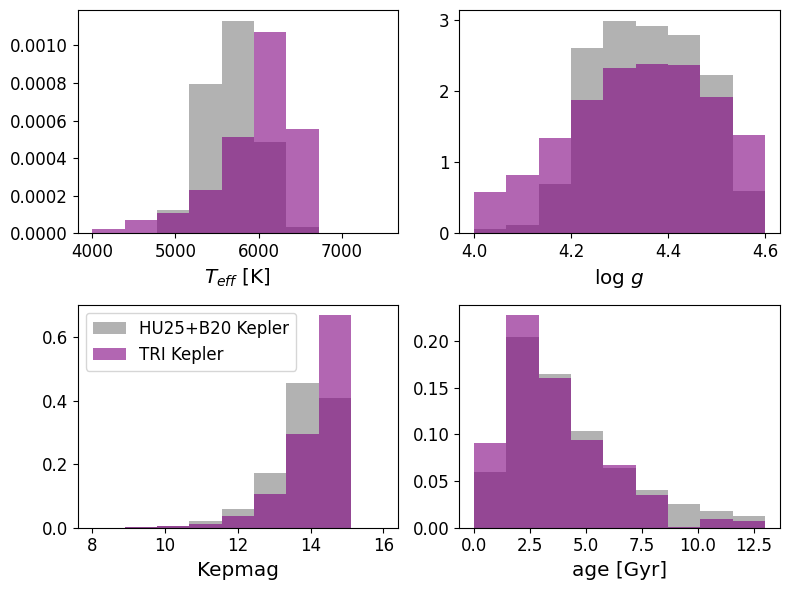

In [15]:
cols = ["iso_teff", "iso_logg", "kepmag", "iso_age"]

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

ax = axes[0]
teff_bins = np.linspace(4000, 7500, 10)
ax.hist(hu25_b20_kepler['Teff'], bins=teff_bins, alpha=0.6, label="HU25+B20 Kepler", density=True, color='gray')
ax.hist(tri_kepler['Teff'], bins=teff_bins, alpha=0.6, label="TRI Kepler", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['Teff'], bins=teff_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r"$T_{eff}$ [K]")

ax = axes[1]
logg_bins = np.linspace(4., 4.6, 10)
ax.hist(hu25_b20_kepler['logg'], bins=logg_bins, alpha=0.6, label="HU25+B20 Kepler", density=True, color='gray')
ax.hist(tri_kepler['logg'], bins=logg_bins, alpha=0.6, label="TRI Kepler", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['logg'], bins=logg_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'log $g$')

ax = axes[2]
kepmag_bins = np.linspace(8, 16, 10)
ax.hist(hu25_b20_kepler['kepmag'], bins=kepmag_bins, alpha=0.6, label="HU25+B20 Kepler", density=True, color='gray')
ax.hist(tri_kepler['Kepler'], bins=kepmag_bins, alpha=0.6, label="TRI Kepler", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['kepmag'], bins=kepmag_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'Kepmag')
ax.legend(loc='upper left')

ax = axes[3]
age_bins = np.linspace(0, 13, 10)
ax.hist(hu25_b20_kepler['age'], bins=age_bins, alpha=0.6, label="HU25+B20 Kepler", density=True, color='gray')
ax.hist(tri_kepler['age'], bins=age_bins, alpha=0.6, label="TRI Kepler", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['age'], bins=age_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'age [Gyr]')

plt.tight_layout()
plt.savefig(path+'plots/tri_vs_sample_params_kepler.png')
plt.show()

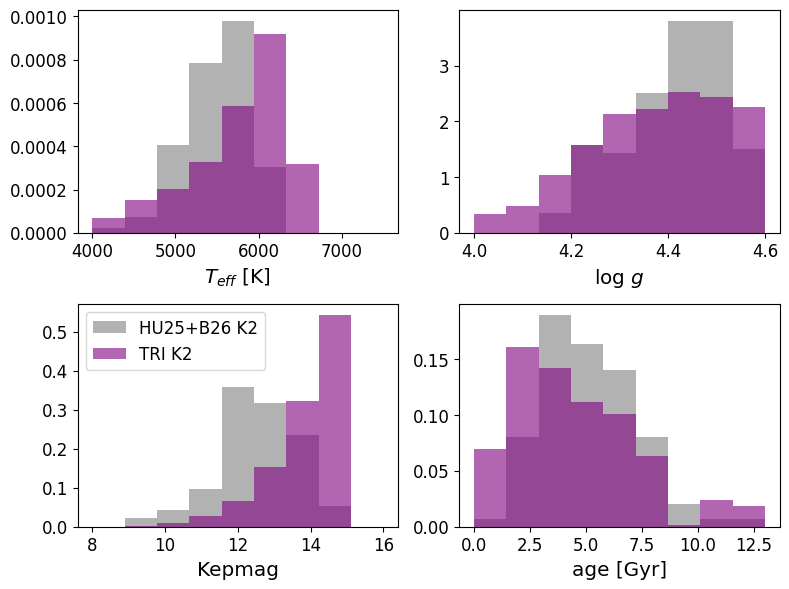

In [20]:
cols = ["iso_teff", "iso_logg", "kepmag", "iso_age"]

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

ax = axes[0]
teff_bins = np.linspace(4000, 7500, 10)
ax.hist(hu25_b25_k2['Teff'], bins=teff_bins, alpha=0.6, label="HU25+B26 K2", density=True, color='gray')
ax.hist(tri_k2['Teff'], bins=teff_bins, alpha=0.6, label="TRI K2", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['Teff'], bins=teff_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r"$T_{eff}$ [K]")

ax = axes[1]
logg_bins = np.linspace(4., 4.6, 10)
ax.hist(hu25_b25_k2['logg'], bins=logg_bins, alpha=0.6, label="HU25+B26 K2", density=True, color='gray')
ax.hist(tri_k2['logg'], bins=logg_bins, alpha=0.6, label="TRI K2", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['logg'], bins=logg_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'log $g$')

ax = axes[2]
kepmag_bins = np.linspace(8, 16, 10)
ax.hist(hu25_b25_k2['k2_kepmag'], bins=kepmag_bins, alpha=0.6, label="HU25+B26 K2", density=True, color='gray')
ax.hist(tri_k2['Kepler'], bins=kepmag_bins, alpha=0.6, label="TRI K2", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['kepmag'], bins=kepmag_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'Kepmag')
ax.legend(loc='upper left')

ax = axes[3]
age_bins = np.linspace(0, 13, 10)
ax.hist(hu25_b25_k2['age'], bins=age_bins, alpha=0.6, label="HU25+B26 K2", density=True, color='gray')
ax.hist(tri_k2['age'], bins=age_bins, alpha=0.6, label="TRI K2", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['age'], bins=age_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'age [Gyr]')

plt.tight_layout()
plt.savefig(path+'plots/tri_vs_sample_params_k2.png')
plt.show()

In [17]:
tri = pd.concat([tri_kepler, tri_k2], ignore_index=True)

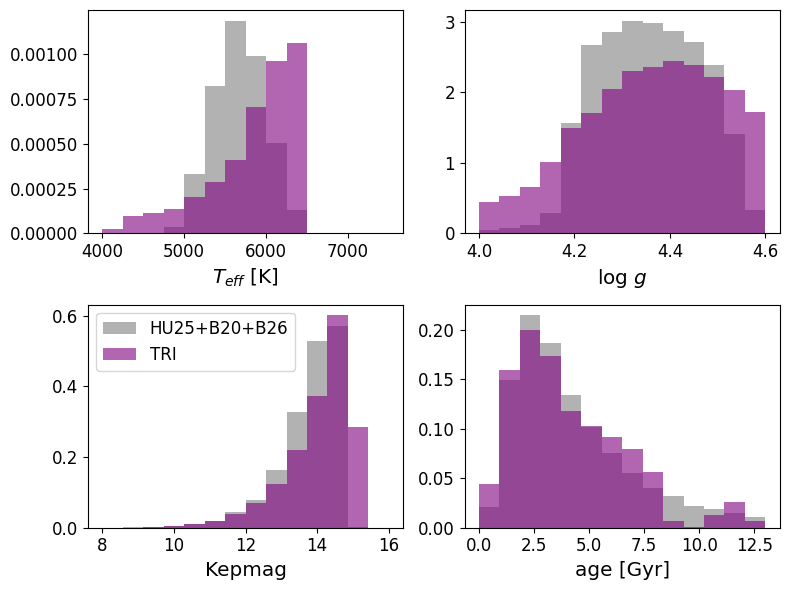

In [19]:
cols = ["iso_teff", "iso_logg", "kepmag", "iso_age"]

fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

ax = axes[0]
teff_bins = np.linspace(4000, 7500, 15)
ax.hist(hu25_b20_kepler_b25_k2_kepmag['Teff'], bins=teff_bins, alpha=0.6, label="HU25+B20+B26", density=True, color='gray')
ax.hist(tri['Teff'], bins=teff_bins, alpha=0.6, label="TRI", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['Teff'], bins=teff_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r"$T_{eff}$ [K]")

ax = axes[1]
logg_bins = np.linspace(4., 4.6, 15)
ax.hist(hu25_b20_kepler_b25_k2_kepmag['logg'], bins=logg_bins, alpha=0.6, label="HU25+B20+B26", density=True, color='gray')
ax.hist(tri['logg'], bins=logg_bins, alpha=0.6, label="TRI", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['logg'], bins=logg_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'log $g$')

ax = axes[2]
kepmag_bins = np.linspace(8, 16, 15)
ax.hist(hu25_b20_kepler_b25_k2_kepmag['kepmag'], bins=kepmag_bins, alpha=0.6, label="HU25+B20+B26", density=True, color='gray')
ax.hist(tri['Kepler'], bins=kepmag_bins, alpha=0.6, label="TRI", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['kepmag'], bins=kepmag_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'Kepmag')
ax.legend(loc='upper left')

ax = axes[3]
age_bins = np.linspace(0, 13, 15)
ax.hist(hu25_b20_kepler_b25_k2_kepmag['age'], bins=age_bins, alpha=0.6, label="HU25+B20+B25", density=True, color='gray')
ax.hist(tri['age'], bins=age_bins, alpha=0.6, label="TRI", density=True, color='purple')
#ax.hist(tri_matched_to_b23_kepler_logg['age'], bins=age_bins, alpha=0.6, label="TRI (match sampled)", density=True, color='steelblue')
ax.set_xlabel(r'age [Gyr]')

plt.tight_layout()
plt.savefig(path+'plots/tri_vs_sample_params.png')
plt.show()

In [126]:
print(np.mean(hu25_b20_kepler['age_err1']), np.mean(hu25_b20_kepler['age_err2']))
print(np.mean(hu25_b25_k2['age_err1']), np.mean(hu25_b25_k2['age_err2']))

2.9370960093236342 -2.129204677892537
7.2561465721040195 4.735007092198582


In [127]:
hu25_b20_kepler_b25_k2_kepmag['frac_age_err1'] = hu25_b20_kepler_b25_k2_kepmag['age_err1'] / hu25_b20_kepler_b25_k2_kepmag['age']
hu25_b20_kepler_b25_k2_kepmag['frac_age_err2'] = np.abs(hu25_b20_kepler_b25_k2_kepmag['age_err2']) / hu25_b20_kepler_b25_k2_kepmag['age']
print(np.mean(hu25_b20_kepler_b25_k2_kepmag['frac_age_err1']), np.mean(hu25_b20_kepler_b25_k2_kepmag['frac_age_err2']))

hu25_b25_k2['frac_age_err1'] = hu25_b25_k2['age_err1'] / hu25_b25_k2['age']
hu25_b25_k2['frac_age_err2'] = np.abs(hu25_b25_k2['age_err2']) / hu25_b25_k2['age']

hu25_b20_kepler['frac_age_err1'] = hu25_b20_kepler['age_err1'] / hu25_b20_kepler['age']
hu25_b20_kepler['frac_age_err2'] = np.abs(hu25_b20_kepler['age_err2']) / hu25_b20_kepler['age']

0.8251202674299741 0.542063649367956


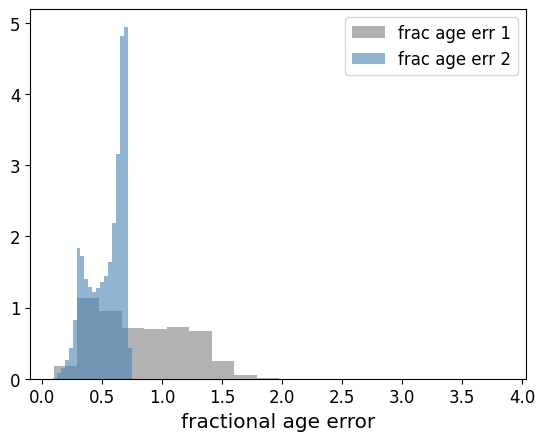

In [128]:
plt.hist(hu25_b20_kepler['frac_age_err1'], bins=20, alpha=0.6, label="frac age err 1", density=True, color='gray')
plt.hist(hu25_b20_kepler['frac_age_err2'], bins=20, alpha=0.6, label="frac age err 2", density=True, color='steelblue')
plt.xlabel('fractional age error')
plt.legend()
plt.show()

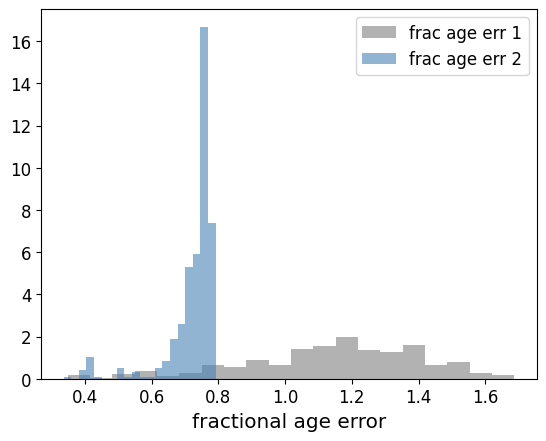

K2 stars with age err < 1:  107
       epic_number     age  age_err1  age_err2
24883  201155177.0  12.004     9.895     8.225
24884  201208431.0  12.079    11.271     8.951
24885  201357643.0   6.347     4.347     3.632
24886  201384232.0   4.473     6.058     3.413
24887  201390608.0   9.101     9.995     6.734
...            ...     ...       ...       ...
25301  251304634.0   9.775    10.982     7.254
25302  251319382.0   3.763     5.175     2.876
25303  251399501.0   2.937     3.427     2.125
25304  251554286.0   6.737     7.236     4.859
25305  251626487.0   9.450     6.617     5.862

[423 rows x 4 columns]


In [129]:
plt.hist(hu25_b25_k2['frac_age_err1'], bins=20, alpha=0.6, label="frac age err 1", density=True, color='gray')
plt.hist(hu25_b25_k2['frac_age_err2'], bins=20, alpha=0.6, label="frac age err 2", density=True, color='steelblue')
plt.xlabel('fractional age error')
plt.legend()
plt.show()

print("K2 stars with age err < 1: ", len(hu25_b25_k2.loc[hu25_b25_k2['frac_age_err1']<1]))
print(hu25_b25_k2[['epic_number', 'age', 'age_err1', 'age_err2']])

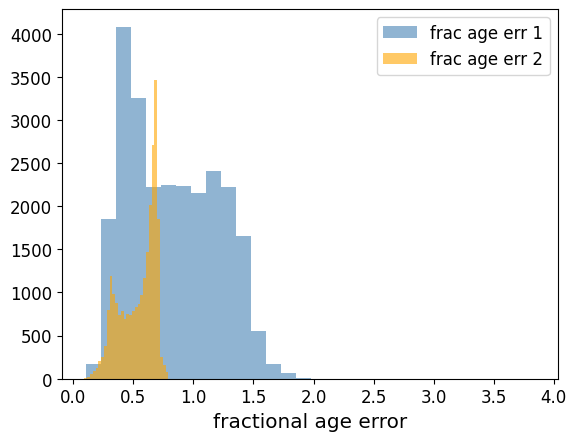

In [130]:
plt.hist(hu25_b20_kepler_b25_k2_kepmag['frac_age_err1'], bins=30, alpha=0.6, label='frac age err 1', color='steelblue')
plt.hist(hu25_b20_kepler_b25_k2_kepmag['frac_age_err2'], bins=30, alpha=0.6, label='frac age err 2', color='orange')
plt.xlabel('fractional age error')
plt.legend()
plt.show()

...this may be a problem.

...oh well?

Try to make bootstrapped stellar sample once, then move this to a more industrial setting

In [131]:
hu25_b20_kepler_b25_k2_kepmag.columns

Index(['Kepler_ID', 'Teff', 'e_Teff', 'logg', 'e_logg', 'Lum', 'e_Lum',
       '[Fe/H]', 'e_[Fe/H]', 'Rad', 'e_Rad', 'Mass', 'e_Mass', 'CDPP75',
       'CDPP6', 'KIC', 'iso_teff', 'iso_logg', 'iso_lum', 'iso_age',
       'iso_age_err1', 'iso_age_err2', 'iso_feh', 'kepid_x', 'source_id', 'ra',
       'dec', 'parallax', 'parallax_error', 'pmra', 'pmra_error', 'pmdec',
       'pmdec_error', 'radial_velocity', 'radial_velocity_error', 'height',
       'EPIC_ID', 'GaiaDR3', 'Campaign', 'CDPP8', 'EPIC', 'L_star', 'Age',
       'E_Age', 'e_Age', 'feh', 'SOURCE_ID', 'ra_error', 'dec_error', 'age',
       'age_err1', 'age_err2', 'source_id_dr3', 'kepid_y', 'kepmag', 'kepid',
       'epic_number', 'k2_kepmag', 'frac_age_err1', 'frac_age_err2'],
      dtype='object')

Everything below here is just testing for make_star.py and detect_planets.py

In [187]:
# draw eccentricities using Van Eylen+ 2019
model_flag = 'rayleigh'

# planet formation history model parameters
threshold = 11 # cosmic age in Gyr; 13.7 minus stellar age, then round
frac1 = 0.33 # frac1 must be < frac2 if comparing cosmic ages
frac2 = 0.33

name_thresh = 11
name_f1 = 33
name_f2 = 33
name = 'step_'+str(name_thresh)+'_'+str(name_f1)+'_'+str(name_f2)
#name = 'monotonic_'+str(name_f1)+'_'+str(name_f2)
#name = 'piecewise_'+str(name_thresh)+'_'+str(name_f1)+'_'+str(name_f2)
try:
    os.mkdir(path+'data/joint/stellar_samples/'+name)
    print(f"Directory '{name}' created")
except FileExistsError:
    print(f"Directory '{name}' already exists")

# for each model, draw around stellar age errors 10 times
for j in tqdm(range(5)): 

    temp_df = hu25_b20_kepler_b25_k2_kepmag.copy() # copy the original DataFrame to avoid modifying it in place during each iteration

    # draw stellar radius, mass, and age using asymmetric errors 
    temp_df['stellar_radius'] = np.random.normal(temp_df['Rad'], temp_df['e_Rad'])
    temp_df = draw_asymmetrically(temp_df, 'age', 'age_err1', 'age_err2', 'age_drawn') # use this bc the psps version uses the same name as our input column
    temp_df['stellar_mass'] = np.random.normal(temp_df['Mass'], temp_df['e_Mass'])
    temp_df['teff_drawn'] = np.random.normal(temp_df['Teff'], temp_df['e_Teff'])

    temp_df['kepler_or_k2'] = np.where(temp_df['Kepler_ID'] > 0, 'Kepler', 'K2')

    ### create a Population object to hold information about the occurrence law governing that specific population
    # THIS IS WHERE YOU CHOOSE THE PLANET FORMATION HISTORY MODEL 
    pop = Population(temp_df['age_drawn'], threshold, frac1, frac2)
    frac_hosts = pop.galactic_occurrence_step(threshold, frac1, frac2)
    #frac_hosts = pop.galactic_occurrence_monotonic(frac1, frac2)
    #frac_hosts = pop.galactic_occurrence_piecewise(frac1, frac2, threshold)
    intact_fracs = scipy.stats.truncnorm.rvs(0, 1, loc=0.18, scale=0.1, size=len(temp_df))  

    alpha_se = np.random.normal(-1., 0.2)
    alpha_sn = np.random.normal(-1.5, 0.1)

    #"""
    # create Star objects, with their planetary systems
    star_data = []
    kepler_or_k2 = []
    for i in tqdm(range(len(temp_df))): # 100
        star = GeneralStar(temp_df['source_id_dr3'].iloc[i], temp_df['age_drawn'].iloc[i], temp_df['stellar_radius'].iloc[i], temp_df['stellar_mass'].iloc[i], temp_df['teff_drawn'].iloc[i], temp_df['CDPP6'].iloc[i], temp_df['height'].iloc[i], alpha_se, alpha_sn, frac_hosts[i], intact_fracs[i], temp_df['kepler_or_k2'].iloc[i])
        star_update = {
            'source_id_dr3': star.GaiaDR3,
            'age': star.age,
            'stellar_radius': star.stellar_radius,
            'stellar_mass': star.stellar_mass,
            'Teff': star.Teff,
            'rrmscdpp06p0': star.rrmscdpp06p0,
            'frac_host': star.frac_host,
            'height': star.height,
            'midplane': star.midplane,
            'prob_intact': star.prob_intact,
            'status': star.status,
            'sigma_incl': star.sigma_incl,
            'num_planets': star.num_planets,
            'periods': star.periods,
            'incls': star.incls,
            'mutual_incls': star.mutual_incls,
            'eccs': star.eccs,
            'omegas': star.omegas,
            'planet_radii': star.planet_radii,
            'kepler_or_k2': star.kepler_or_k2,
            'se_or_sn': star.se_or_sn
        }
        star_data.append(star_update)
        pop.add_child(star)

        # if temp_df['Kepler_ID'].iloc[i] > 0:
        #     kepler_or_k2.append('Kepler')
        # elif temp_df['EPIC_ID'].iloc[i] > 0:
        #     kepler_or_k2.append('K2')

    # convert back to DataFrame
    berger_kepler_all = pd.DataFrame.from_records(star_data)
    #print(berger_kepler_all)
    #"""

    berger_kepler_planets = berger_kepler_all.loc[berger_kepler_all.num_planets > 0]
    #berger_kepler_planets = berger_kepler_planets.loc[(berger_kepler_planets['periods'] <= 40) & (berger_kepler_planets['periods'] > 1)] # limit periods to fairly compare with Zink+ 2023
    #berger_kepler_planets = berger_kepler_planets.loc[berger_kepler_planets['planet_radii'] <= 4.]

    #print(berger_kepler_all)
    f = len(berger_kepler_planets)/len(berger_kepler_all)
    #print("f: ", f)

    berger_kepler_all.to_csv(path+'data/joint/stellar_samples/'+name+'/'+name+'_'+str(j)+'.csv')

Directory 'step_11_33_33' already exists


  0%|          | 0/5 [00:03<?, ?it/s]


AttributeError: 'GeneralStar' object has no attribute 'kepler_or_k2'

Detect and collect planets

In [164]:
berger_kepler_all

,source_id_dr3,age,stellar_radius,stellar_mass,Teff,rrmscdpp06p0,frac_host,height,midplane,prob_intact,status,sigma_incl,num_planets,periods,incls,mutual_incls,eccs,omegas,planet_radii,kepler_or_k2
0,2.104246e+18,10.085859,0.8782536718639026,0.8980246925891924,5284.822610425924,108.031,0.33,0.2904513258277449,0.753385,0.261499,no-planet,0.13962634015954636,NaN,None,None,None,None,None,None,Kepler
1,2.104266e+18,2.732323,1.4101147743673075,1.0881914600613927,5772.223849836994,47.347,0.33,0.3448992545963054,1.315285,0.189651,no-planet,0.13962634015954636,NaN,None,None,None,None,None,None,Kepler
2,2.103735e+18,2.207071,1.0251938195907864,0.8701818440687129,5373.020979277044,144.379,0.33,0.5360488920537895,0.692997,0.183917,no-planet,0.13962634015954636,NaN,None,None,None,None,None,None,Kepler
3,2.104566e+18,1.681818,0.9939975853638653,0.990718691940173,5568.201101313686,86.102,0.33,0.2849520496794743,-0.931113,0.188517,no-planet,0.13962634015954636,NaN,None,None,None,None,None,None,Kepler
4,2.130331e+18,7.459596,1.1110125599382639,1.0839697272133724,5799.873664144009,82.344,0.33,0.6262538138285121,-1.156052,0.251534,no-planet,0.13962634015954636,NaN,None,None,None,None,None,None,Kepler
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25301,6.320547e+17,9.166667,0.672397804366821,0.6584763542066591,4578.589710295991,69.53,0.33,0.2585106616317796,-0.595266,0.243115,no-planet,0.13962634015954636,NaN,None,None,None,None,None,None,K2
25302,6.326344e+17,3.388889,1.005457406561067,1.0596454663117492,5766.656647510123,50.074,0.33,0.1588962303566613,0.928554,0.267933,no-planet,0.13962634015954636,NaN,None,None,None,None,None,None,K2
25303,6.883079e+17,3.388889,1.0479130816304008,0.9494124033039496,5644.645537751415,77.016,0.33,0.3771099904007398,-1.164551,0.246248,intact,0.03490658503988659,6.0,"[2.7273545265197754, 8.28271770477295, 24.7878...","[-1.1696931926374512, -1.1548207754898554, -1....","[0.005141813186116506, -0.00973060396147929, 0...","[0.01879212421280424, 0.041283426984656306, 0....","[2.589602380186146, 6.039183827277815, 3.71161...","[1.385858585858586, 2.04040404040404, 2.444444...",K2
25304,3.638011e+18,12.186869,0.8710740109551401,0.8480123104168917,5637.458658699925,106.246,0.33,0.3264358550825509,-1.496173,0.224074,no-planet,0.13962634015954636,NaN,None,None,None,None,None,None,K2


In [165]:
berger_kepler_planets

,source_id_dr3,age,stellar_radius,stellar_mass,Teff,rrmscdpp06p0,frac_host,height,midplane,prob_intact,status,sigma_incl,num_planets,periods,incls,mutual_incls,eccs,omegas,planet_radii,kepler_or_k2
17,2.081902e+18,2.863636,1.4177506303089695,1.1432113659592493,5529.235285702324,71.095,0.33,0.2570859081073893,0.883810,0.201487,disrupted,0.13962634015954636,2.0,"[2.297027826309204, 15.141727447509766]","[0.8976910177947669, 0.9413971788106644]","[-0.013881515689763702, -0.05758767670566123]","[0.0452212767288315, 0.09231484741117446]","[0.593405187911946, 4.866222905644372]","[3.1515151515151514, 2.808080808080808]",Kepler
20,2.101972e+18,7.853535,1.270744928070399,1.1078368129618488,5602.929852351151,83.923,0.33,0.2538703195139604,0.430600,0.196008,disrupted,0.13962634015954636,1.0,[98.28728485107422],[0.14785358586548397],[0.28274677860270375],[0.24951170876646123],[3.2878558228060144],[3.5353535353535355],Kepler
21,2.081908e+18,5.095960,1.254589635310768,1.1344152136154875,5475.168548517669,87.585,0.33,0.1859082606377427,0.889948,0.198186,disrupted,0.13962634015954636,1.0,[213.4231414794922],[0.945563619891622],[-0.055615623002297276],[0.3666225799270781],[3.7603990562484633],[2.404040404040404],Kepler
23,2.126759e+18,4.833333,1.31383631773943,1.3978276056583536,5906.828428727157,57.289,0.33,0.3481865932330873,-0.317723,0.247398,intact,0.03490658503988659,5.0,"[6.607305526733398, 57.539920806884766, 81.306...","[-0.30519130636854186, -0.3236191823679634, -0...","[-0.012531748029401824, 0.0058961279700197045,...","[0.08021392181543546, 0.02692573246106833, 0.0...","[3.3930665016158597, 2.968691689303659, 5.2461...","[1.4343434343434343, 1.9515151515151514, 2.303...",Kepler
24,2.086400e+18,8.510101,0.7878570674395624,0.8057763601810688,5514.730098350651,68.812,0.33,0.1199330805687391,-0.652209,0.240263,disrupted,0.13962634015954636,1.0,[29.66002655029297],[-0.5871322670296079],[-0.06507667785478455],[0.37010413891577],[1.3130994413867725],[1.2404040404040404],Kepler
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25293,6.214868e+18,12.318182,1.011702698170795,1.0059577762161669,5673.81137404055,111.66,0.33,0.3738304406889716,0.714298,0.277876,disrupted,0.13962634015954636,1.0,[127.59064483642578],[0.4470364253632055],[0.2672611841726374],[0.2738116347534306],[5.035571945173986],[2.1616161616161618],K2
25294,6.231307e+18,12.318182,1.2025608323831531,0.9491756112324196,5000.957326902403,96.913,0.33,0.1906627560162682,0.448590,0.249600,intact,0.03490658503988659,6.0,"[2.40724515914917, 4.339737892150879, 5.676582...","[0.4779431010037523, 0.4946791009739538, 0.405...","[-0.029353407189161962, -0.04608940715936344, ...","[0.08922199978798555, 0.020181439625169505, 0....","[1.1944310289585884, 6.165920595771293, 1.7872...","[1.7575757575757576, 1.2161616161616162, 1.2, ...",K2
25299,6.266770e+18,2.075758,0.9619266722262058,0.7322682161168206,5104.884331316125,61.369,0.33,0.1758523322582809,0.809244,0.246260,disrupted,0.13962634015954636,2.0,"[2.0369720458984375, 4.813660144805908]","[0.575642230472426, 0.8057338631252937]","[0.2336014942042135, 0.0035098615513458054]","[0.07773968897718565, 0.10876851153779388]","[1.7476864249991142, 5.1443546264910385]","[3.1515151515151514, 2.525252525252525]",K2
25300,6.266870e+18,2.601010,0.8483728592380939,0.751291675302046,4760.990743440008,113.622,0.33,0.1372957520468644,-1.294889,0.243810,disrupted,0.13962634015954636,1.0,[12.961823463439941],[-1.2265897008171047],[-0.06829956031964546],[0.17030811409107025],[1.7736260964487378],[2.0606060606060606],K2


In [ ]:
sim = sorted(glob(path+'data/joint/stellar_samples/' + name + '/' + name + '*'))

heights = []
ages = []
fs = []
physical_planet_occurrences_all = []
detected_planet_occurrences_all = []
adjusted_planet_occurrences_all = []
transit_multiplicities_all = []
geom_transit_multiplicities_all = []
physical_planet_occurrences_kepler = []
detected_planet_occurrences_kepler = []
adjusted_planet_occurrences_kepler = []
physical_planet_occurrences_k2 = []
detected_planet_occurrences_k2 = []
adjusted_planet_occurrences_k2 = []
completeness_all = []
completeness_kepler = []
completeness_k2 = []

period_grid = np.logspace(np.log10(1), np.log10(40), 10)
radius_grid = np.linspace(1, 4, 10)
#height_bins = np.array([0., 150, 250, 400, 650, 3000]) 
height_bins = np.array([0., 120, 200, 300, 500, 800, 1500]) # the actual Zink Fig 12 height bins
height_bins = np.logspace(2, 3, 6) # ah, so the above are the midpoints of the actual bins they used, I guess
height_bin_midpoints = 0.5 * (np.logspace(2,3,6)[1:] + np.logspace(2,3,6)[:-1])
for i in tqdm(range(len(sim))):

    berger_kepler_all = pd.read_csv(sim[i], sep=',') #, on_bad_lines='skip'
    #berger_kepler_all = pd.read_csv(path+'data/berger_gala/'+name+'.csv')
    
    num_hosts = berger_kepler_all.loc[berger_kepler_all['num_planets']>0]
    #print("f: ", len(num_hosts)/len(berger_kepler_all))
    f = len(num_hosts)/len(berger_kepler_all)
    fs.append(f)

    berger_kepler_all = berger_kepler_all.dropna(subset=['height'])

    berger_kepler_all['height'] = berger_kepler_all['height'] * 1000 # kpc --> pc
    berger_kepler_all['periods'] = berger_kepler_all['periods'].apply(literal_eval_w_exceptions)
    berger_kepler_all['planet_radii'] = berger_kepler_all['planet_radii'].apply(literal_eval_w_exceptions)
    berger_kepler_all['incls'] = berger_kepler_all['incls'].apply(literal_eval_w_exceptions)
    berger_kepler_all['mutual_incls'] = berger_kepler_all['mutual_incls'].apply(literal_eval_w_exceptions)
    berger_kepler_all['eccs'] = berger_kepler_all['eccs'].apply(literal_eval_w_exceptions)
    berger_kepler_all['omegas'] = berger_kepler_all['omegas'].apply(literal_eval_w_exceptions)

    # split into Kepler and K2, since they have different detection efficiencies (bc different baselines and different pointings)
    kepler_temp = berger_kepler_all.loc[berger_kepler_all['kepler_or_k2'] == 'Kepler']
    k2_temp = berger_kepler_all.loc[berger_kepler_all['kepler_or_k2'] == 'K2']

    heights.append(np.array(berger_kepler_all['height']))
    ages.append(np.array(berger_kepler_all['age']))

    # denominators
    berger_kepler_all['height_bins'] = pd.cut(berger_kepler_all['height'], bins=height_bins, include_lowest=True)
    berger_kepler_counts = np.array(berger_kepler_all.groupby(['height_bins']).count().reset_index()['source_id_dr3'])

    kepler_temp['height_bins'] = pd.cut(kepler_temp['height'], bins=height_bins, include_lowest=True)
    kepler_temp_counts = np.array(kepler_temp.groupby(['height_bins']).count().reset_index()['source_id_dr3'])

    k2_temp['height_bins'] = pd.cut(k2_temp['height'], bins=height_bins, include_lowest=True)
    k2_temp_counts = np.array(k2_temp.groupby(['height_bins']).count().reset_index()['source_id_dr3'])

    # isolate planet hosts and bin them by galactic height
    berger_kepler_planets = berger_kepler_all.loc[berger_kepler_all['num_planets'] > 0]
    berger_kepler_planets = berger_kepler_planets.explode(['periods', 'planet_radii', 'incls', 'mutual_incls', 'eccs', 'omegas']).reset_index(drop=True)

    # select planets that are relevant to this study 
    berger_kepler_planets = berger_kepler_planets.loc[(berger_kepler_planets['periods'] <= 40) & (berger_kepler_planets['periods'] > 1)] # limit periods to fairly compare with Zink+ 2023
    berger_kepler_planets = berger_kepler_planets.loc[berger_kepler_planets['planet_radii'] <= 4.] # limit radii to fairly compare with SEs in Zink+ 2023 (2)...or how about include SNs too (4)?

    # split into Kepler and K2 for numerators
    kepler_temp_planets = berger_kepler_planets.loc[berger_kepler_planets['kepler_or_k2']=='Kepler']
    k2_temp_planets = berger_kepler_planets.loc[berger_kepler_planets['kepler_or_k2']=='K2']

    # count by height bin, for all, Kepler only, and K2 only
    berger_kepler_planets_counts = np.array(berger_kepler_planets.groupby(['height_bins']).count().reset_index()['age'])
    physical_planet_occurrence = 100 * berger_kepler_planets_counts/berger_kepler_counts 
    physical_planet_occurrences.append(physical_planet_occurrence)

    kepler_temp_planets_counts = np.array(kepler_temp_planets.groupby(['height_bins']).count().reset_index()['age'])
    physical_planet_occurrence_kepler = 100 * kepler_temp_planets_counts/kepler_temp_counts 
    physical_planet_occurrences_kepler.append(physical_planet_occurrence_kepler)

    k2_temp_planets_counts = np.array(k2_temp_planets.groupby(['height_bins']).count().reset_index()['age'])
    physical_planet_occurrence_k2 = 100 * k2_temp_planets_counts/k2_temp_counts 
    physical_planet_occurrences_k2.append(physical_planet_occurrence_k2)
    

    ### Simulate detections from these synthetic systems
    prob_detections, transit_statuses, sn, geom_transit_statuses = simulate_transit.calculate_transit_vectorized(berger_kepler_planets.periods, 
                                    berger_kepler_planets.stellar_radius, berger_kepler_planets.planet_radii,
                                    berger_kepler_planets.eccs, 
                                    berger_kepler_planets.incls, 
                                    berger_kepler_planets.omegas, berger_kepler_planets.stellar_mass,
                                    berger_kepler_planets.rrmscdpp06p0, angle_flag=True) 

    prob_detections_kepler, transit_statuses_kepler, sn_kepler, geom_transit_statuses_kepler = simulate_transit.calculate_transit_vectorized(kepler_temp_planets.periods, 
                                    kepler_temp_planets.stellar_radius, kepler_temp_planets.planet_radii,
                                    kepler_temp_planets.eccs, 
                                    kepler_temp_planets.incls, 
                                    kepler_temp_planets.omegas, kepler_temp_planets.stellar_mass,
                                    kepler_temp_planets.rrmscdpp06p0, angle_flag=True) 

    prob_detections_k2, transit_statuses_k2, sn_k2, geom_transit_statuses_k2 = simulate_transit.calculate_transit_vectorized(k2_temp_planets.periods, 
                                    k2_temp_planets.stellar_radius, k2_temp_planets.planet_radii,
                                    k2_temp_planets.eccs, 
                                    k2_temp_planets.incls, 
                                    k2_temp_planets.omegas, k2_temp_planets.stellar_mass,
                                    k2_temp_planets.rrmscdpp06p0, angle_flag=True) 


    berger_kepler_planets['transit_status'] = transit_statuses[0]
    berger_kepler_planets['prob_detections'] = prob_detections[0]
    berger_kepler_planets['sn'] = sn

    kepler_temp_planets['transit_status'] = transit_statuses_kepler[0]
    kepler_temp_planets['prob_detections'] = prob_detections_kepler[0]
    kepler_temp_planets['sn'] = sn_kepler

    k2_temp_planets['transit_status'] = transit_statuses_k2[0]
    k2_temp_planets['prob_detections'] = prob_detections_k2[0]
    k2_temp_planets['sn'] = sn_k2

    # need kepid to be str or tuple, else unhashable type when groupby.count()
    berger_kepler_planets['source_id_dr3'] = berger_kepler_planets['source_id_dr3'].apply(str) 
    kepler_temp_planets['source_id_dr3'] = kepler_temp_planets['source_id_dr3'].apply(str) 
    k2_temp_planets['source_id_dr3'] = k2_temp_planets['source_id_dr3'].apply(str) 

    # isolate detected transiting planets
    berger_kepler_transiters = berger_kepler_planets.loc[berger_kepler_planets['transit_status']==1]
    kepler_temp_transiters = kepler_temp_planets.loc[kepler_temp_planets['transit_status']==1]
    k2_temp_transiters = k2_temp_planets.loc[k2_temp_planets['transit_status']==1]

    ### Completeness
    # Calculate completeness map
    #if (k==0) or (k==1) or (k==2) or (k==3) or (k==4):
    completeness_map, piv_physical, piv_detected = simulate_helpers.completeness(berger_kepler_planets, berger_kepler_transiters)
    completeness_threshold = 0.003 # completeness threshold under which period/radius cell is not counted; 0.5% results in full recovery, but let's round up to 1%
    completeness_map = completeness_map.mask(completeness_map < completeness_threshold) # assert that completeness fractions lower than 1% are statistically insignificant
    completeness_all.append(completeness_map)

    ### Calculate transit multiplicity and other Population-wide demographics
    #simulate_helpers.collect_galactic(berger_kepler_planets)

    # compute transit multiplicity
    transit_multiplicity = berger_kepler_transiters.groupby('source_id_dr3').count()['transit_status'].reset_index().groupby('transit_status').count().reset_index().source_id_dr3
    transit_multiplicity = transit_multiplicity.to_list()
    transit_multiplicity += [0.] * (6 - len(transit_multiplicity)) # pad with zeros to match length of k
    transit_multiplicities_all.append(transit_multiplicity)

    # also calculate the geometric transit multiplicity
    geom_transiters_berger_kepler = berger_kepler_planets.loc[berger_kepler_planets['geom_transit_status']==1]
    geom_transit_multiplicity = geom_transiters_berger_kepler.groupby('source_id_dr3').count()['geom_transit_status'].reset_index().groupby('geom_transit_status').count().reset_index().source_id_dr3
    geom_transit_multiplicity = geom_transit_multiplicity.to_list()
    geom_transit_multiplicity += [0.] * (6 - len(geom_transit_multiplicity)) # pad with zeros to match length of k
    geom_transit_multiplicities_all.append(geom_transit_multiplicity)

    # calculate detected occurrence rate 
    berger_kepler_transiters_counts = np.array(berger_kepler_transiters.groupby(['height_bins']).count().reset_index()['source_id_dr3'])
    detected_planet_occurrence = berger_kepler_transiters_counts/berger_kepler_counts
    detected_planet_occurrences_all.append(detected_planet_occurrence)

    berger_kepler_transiters1 = berger_kepler_transiters.loc[(berger_kepler_transiters['height'] > 100) & (berger_kepler_transiters['height'] <= np.logspace(2,3,6)[1])]
    berger_kepler_transiters2 = berger_kepler_transiters.loc[(berger_kepler_transiters['height'] > np.logspace(2,3,6)[1]) & (berger_kepler_transiters['height'] <= np.logspace(2,3,6)[2])]
    berger_kepler_transiters3 = berger_kepler_transiters.loc[(berger_kepler_transiters['height'] > np.logspace(2,3,6)[2]) & (berger_kepler_transiters['height'] <= np.logspace(2,3,6)[3])]
    berger_kepler_transiters4 = berger_kepler_transiters.loc[(berger_kepler_transiters['height'] > np.logspace(2,3,6)[3]) & (berger_kepler_transiters['height'] <= np.logspace(2,3,6)[4])]
    berger_kepler_transiters5 = berger_kepler_transiters.loc[(berger_kepler_transiters['height'] > np.logspace(2,3,6)[4]) & (berger_kepler_transiters['height'] <= 1000)]

    #"""
    len_berger_kepler_transiters1, _ = simulate_helpers.adjust_for_completeness2(berger_kepler_transiters1, completeness_map, radius_grid, period_grid) #completeness_map_np vs completeness_map
    len_berger_kepler_transiters2, _ = simulate_helpers.adjust_for_completeness2(berger_kepler_transiters2, completeness_map, radius_grid, period_grid)
    len_berger_kepler_transiters3, _ = simulate_helpers.adjust_for_completeness2(berger_kepler_transiters3, completeness_map, radius_grid, period_grid)
    len_berger_kepler_transiters4, _ = simulate_helpers.adjust_for_completeness2(berger_kepler_transiters4, completeness_map, radius_grid, period_grid)
    len_berger_kepler_transiters5, _ = simulate_helpers.adjust_for_completeness2(berger_kepler_transiters5, completeness_map, radius_grid, period_grid)
    len_berger_kepler_transiters = np.array([len_berger_kepler_transiters1, len_berger_kepler_transiters2, len_berger_kepler_transiters3, len_berger_kepler_transiters4, len_berger_kepler_transiters5])

    #len_berger_kepler_recovered, recovered_piv = simulate_helpers.adjust_for_completeness(berger_kepler_transiters, completeness_map, radius_grid, period_grid)
    """
    print("physical piv: ", piv_physical)
    print("detected piv: ", piv_detected)
    print("completeness map: ", completeness_map)
    print("recovered piv: ", recovered_piv)
    print("stars: ", berger_kepler_counts)
    print("number of physical planets; number of stars: ", len(berger_kepler_planets), np.sum(berger_kepler_counts))
    print("physical planet occurrence: ", 100 * len(berger_kepler_planets)/np.sum(berger_kepler_counts))
    print("recovered total vs physical total: ", 100 * len_berger_kepler_recovered/np.sum(berger_kepler_counts), np.sum(physical_planet_occurrence))
    print(100 * len_berger_kepler_transiters1/berger_kepler_counts[0], physical_planet_occurrence[0])
    print(100 * len_berger_kepler_transiters1/berger_kepler_counts[1], physical_planet_occurrence[1])
    print(100 * len_berger_kepler_transiters1/berger_kepler_counts[2], physical_planet_occurrence[2])
    print(100 * len_berger_kepler_transiters1/berger_kepler_counts[3], physical_planet_occurrence[3])
    print(100 * len_berger_kepler_transiters5/berger_kepler_counts[4], physical_planet_occurrence[4])
    print(100 * len_berger_kepler_transiters1/berger_kepler_counts[5], physical_planet_occurrence[5])
    """

    #len_berger_kepler_transiters1, _ = simulate_helpers.adjust_for_completeness2(berger_kepler_transiters1, completeness_map_np, radius_grid, period_grid) #completeness_map_np vs completeness_map
    #len_berger_kepler_transiters2, _ = simulate_helpers.adjust_for_completeness2(berger_kepler_transiters2, completeness_map_np, radius_grid, period_grid)
    #len_berger_kepler_transiters3, _ = simulate_helpers.adjust_for_completeness2(berger_kepler_transiters3, completeness_map_np, radius_grid, period_grid)
    #len_berger_kepler_transiters4, _ = simulate_helpers.adjust_for_completeness2(berger_kepler_transiters4, completeness_map_np, radius_grid, period_grid)
    #len_berger_kepler_transiters5, _ = simulate_helpers.adjust_for_completeness2(berger_kepler_transiters5, completeness_map_np, radius_grid, period_grid)
    #len_berger_kepler_transiters6, _ = simulate_helpers.adjust_for_completeness2(berger_kepler_transiters6, completeness_map_np, radius_grid, period_grid)
    #len_berger_kepler_transiters7, _ = simulate_helpers.adjust_for_completeness2(berger_kepler_transiters7, completeness_map_np, radius_grid, period_grid)
    #len_berger_kepler_transiters8, _ = simulate_helpers.adjust_for_completeness2(berger_kepler_transiters8, completeness_map_np, radius_grid, period_grid)
    #len_berger_kepler_transiters9, _ = simulate_helpers.adjust_for_completeness2(berger_kepler_transiters9, completeness_map_np, radius_grid, period_grid)
    #len_berger_kepler_transiters = np.array([len_berger_kepler_transiters1, len_berger_kepler_transiters2, len_berger_kepler_transiters3, len_berger_kepler_transiters4, len_berger_kepler_transiters5, len_berger_kepler_transiters6, len_berger_kepler_transiters7, len_berger_kepler_transiters8, len_berger_kepler_transiters9])

    adjusted_planet_occurrence = len_berger_kepler_transiters/berger_kepler_counts
    adjusted_planet_occurrences_all.append(adjusted_planet_occurrence)
    #"""


# one-time creation of empirical completeness map, using the first detection of each of the 30 Populations and averaging them
#print("COMPLETENESS MAPS")
#print(completeness_all)

mean_completeness = np.nanmean(completeness_all, axis=0)
std_completeness = np.nanstd(completeness_all, axis=0)
#print(mean_completeness)
#print(std_completeness)
#utils.plot_completeness(mean_completeness, std_completeness, radius_grid, period_grid)
#pd.DataFrame(np.nanmean(completeness_all, axis=0)).to_csv(path+'data/completeness_map_empirical'+name+'.csv', index=False)

print("")
print("f: ", np.mean(fs), np.std(fs))
print("")

mean_physical_planet_occurrences = np.nanmean(physical_planet_occurrences, axis=0)
yerr = np.std(physical_planet_occurrences, axis=0)
print("mean physical planet occurrences, and yerr: ", mean_physical_planet_occurrences, yerr, np.sum(mean_physical_planet_occurrences))

mean_recovered_planet_occurrences = 100 * np.nanmean(adjusted_planet_occurrences_all, axis=0)
yerr_recovered = 100 * np.std(adjusted_planet_occurrences_all, axis=0)
print("recovered planet occurrences, and yerr: ", mean_recovered_planet_occurrences, yerr_recovered, np.sum(mean_recovered_planet_occurrences))

mean_detected_planet_occurrences = 100 * np.nanmean(detected_planet_occurrences_all, axis=0)
yerr_detected = 100 * np.std(detected_planet_occurrences_all, axis=0)
print("detected occurrence: ", mean_detected_planet_occurrences)

heights = np.concatenate(heights)
ages = np.concatenate(ages)

### MAKE RESULT PLOT
zink_sn_kepler = pd.DataFrame({'scale_height': np.array([120., 200., 300., 500., 800.]), 'occurrence': np.array([38, 29, 23, 24, 17]), 'occurrence_err1': np.array([5, 3, 2, 2, 4]), 'occurrence_err2': np.array([6, 3, 2, 4, 4])})
zink_se_kepler = pd.DataFrame({'scale_height': np.array([120., 200., 300., 500., 800.]), 'occurrence': np.array([28, 29, 25, 27, 18]), 'occurrence_err1': np.array([5, 3, 3, 4, 4]), 'occurrence_err2': np.array([5, 3, 3, 3, 4])})
zink_kepler_occurrence = np.array([38, 29, 23, 24, 17])+np.array([28, 29, 25, 27, 18])
zink_kepler_occurrence_err1 = np.round(np.sqrt((zink_sn_kepler['occurrence_err1'])**2 + (zink_se_kepler['occurrence_err1']**2)), 2)
zink_kepler_occurrence_err2 = np.round(np.sqrt((zink_sn_kepler['occurrence_err2'])**2 + (zink_se_kepler['occurrence_err2']**2)), 2)
zink_kepler = pd.DataFrame({'scale_height': np.array([120., 200., 300., 500., 800.]), 'occurrence': zink_kepler_occurrence, 'occurrence_err1': zink_kepler_occurrence_err1, 'occurrence_err2': zink_kepler_occurrence_err2})

z_max = np.logspace(2, 3.02, 100)
def model(x, tau, occurrence):

    dln = 0.0011
    scaleMax= 1000
    scaleMin = 100
    const = (scaleMax)**(tau+1)/(tau+1) - ((scaleMin)**(tau+1)/(tau+1))
    planet_yield = occurrence * x**(tau)/const/dln * 100
    
    return planet_yield

### but first, fit a power law 
def power_model(x, yerr, y=None):

    tau = numpyro.sample("tau", dist.Uniform(-1., 1.))
    occurrence = numpyro.sample("occurrence", dist.Uniform(0.01, 1.))

    dln = 0.0011
    scaleMax= 1000
    scaleMin = 100
    const = (scaleMax)**(tau+1)/(tau+1) - ((scaleMin)**(tau+1)/(tau+1))
    planet_yield = occurrence * x**(tau)/const/dln * 100
    #print("planet yield: ", planet_yield)
    #print("yerr: ", yerr)
    #print("y: ", y)
    #print("tau: ", tau)
    #print("occurrence: ", occurrence)
    #print("sample model: ", model(z_max, tau, occurrence))
    #quit()
    with numpyro.plate("data", len(x)):
        numpyro.sample("planet_yield", dist.Normal(planet_yield, yerr), obs=y)

# find MAP solution
init_params = {
    "tau": -0.35,
    "occurrence": 0.3,
}

run_optim = numpyro_ext.optim.optimize(
        power_model, init_strategy=numpyro.infer.init_to_median()
    )
print(height_bins[:-1], yerr_recovered, mean_recovered_planet_occurrences)
opt_params = run_optim(jax.random.PRNGKey(5), height_bin_midpoints, yerr_recovered, y=mean_recovered_planet_occurrences)
#print("opt params: ", opt_params)

# sample posteriors for best-fit model to simulated data
sampler = infer.MCMC(
    infer.NUTS(power_model, dense_mass=True,
        regularize_mass_matrix=False,
        init_strategy=numpyro.infer.init_to_value(values=opt_params)), 
    num_warmup=5000,
    num_samples=10000,
    num_chains=4,
    progress_bar=True,
)

sampler.run(jax.random.PRNGKey(0), height_bin_midpoints, yerr_recovered, y=mean_recovered_planet_occurrences)
inf_data = az.from_numpyro(sampler)
print(az.summary(inf_data))

tau_ours = inf_data.posterior.data_vars['tau'].mean().values
print("tau: ", tau_ours)
tau_std = inf_data.posterior.data_vars['tau'].std().values
print("tau std: ", tau_std)

occurrence_ours = inf_data.posterior.data_vars['occurrence'].mean().values
print("occurrence: ", occurrence_ours)
occurrence_std = inf_data.posterior.data_vars['occurrence'].std().values
print("occurrence std: ", occurrence_std)

### set up plotting
fig, ax1 = plt.subplots(1, 1, figsize=(10, 5))
left, bottom, width, height = [0.16, 0.25, 0.25, 0.25]
ax2 = fig.add_axes([left, bottom, width, height])

# zink model
# calculate all models so that we can take one-sigma envelope
yield_max = []
yield_min = []
models_se = []
models_sn = []
zink_csv = pd.read_csv(path+'data/SupEarths_combine_GaxScale_teff_fresh.csv')
zink_csv_sn = pd.read_csv(path+'data/SubNeptunes_combine_GaxScale_teff_fresh.csv')

for i in range(len(zink_csv)):
    row = zink_csv.iloc[i]
    models_se.append(model(z_max, row['Tau'], row['Occurrence']))
zink_csv['model'] = models_se

for j in range(len(zink_csv_sn)):
    row = zink_csv_sn.iloc[i]
    models_sn.append(model(z_max, row['Tau'], row['Occurrence']))
zink_csv_sn['model'] = models_sn
sum_model = zink_csv['model'] + zink_csv_sn['model']
for temp_list in zip_longest(*sum_model):
    yield_max.append(np.percentile(temp_list, 84)) # plus one sigma
    yield_min.append(np.percentile(temp_list, 16)) # minus one sigma
ax1.fill_between(z_max, yield_max, yield_min, color='red', alpha=0.3, label='Zink+ 2023 posteriors') #03acb1

# zink+ 2023 data
ax1.errorbar(x=height_bin_midpoints, y=zink_kepler['occurrence'], yerr=(zink_kepler['occurrence_err1'], zink_kepler['occurrence_err2']), fmt='o', color='red', alpha=0.5, capsize=3, elinewidth=1, markeredgewidth=1, label='Zink+ 2023 Kepler data')

"""
### get combined SE and SN tau and occurrence for Zink23
print(yerr_recovered, mean_recovered_planet_occurrences)
print(0.5 * (np.array(zink_kepler['occurrence_err1']) + np.array(zink_kepler['occurrence_err2'])), np.array(zink_kepler['occurrence']))
opt_params = run_optim(jax.random.PRNGKey(5), height_bin_midpoints, 0.5 * (np.array(zink_kepler['occurrence_err1']) + np.array(zink_kepler['occurrence_err2'])), y=np.array(zink_kepler['occurrence']))
#print("opt params: ", opt_params)

# sample posteriors for best-fit model to simulated data
sampler = infer.MCMC(
    infer.NUTS(power_model, dense_mass=True,
        regularize_mass_matrix=False,
        init_strategy=numpyro.infer.init_to_value(values=opt_params)), 
    num_warmup=10000,
    num_samples=10000,
    num_chains=8,
    progress_bar=True,
)
sampler.run(jax.random.PRNGKey(0), height_bin_midpoints, 0.5 * (np.array(zink_kepler['occurrence_err1']) + np.array(zink_kepler['occurrence_err2'])), y=np.array(zink_kepler['occurrence']))
inf_data = az.from_numpyro(sampler)
print(az.summary(inf_data))
quit()
"""

# our simulated data
#height_bins_shifted1 = height_bins[1:] + np.array([7, 15, 18, 32, 48])
#height_bins_shifted1 = np.logspace(2.01, 3.01, 6)[1:]
height_bin_midpoints1 = 0.5 * (np.logspace(2.02,3.02,6)[1:] + np.logspace(2.02,3.02,6)[:-1])
ax1.errorbar(x=height_bin_midpoints1, y=mean_physical_planet_occurrences, yerr=yerr, fmt='o', capsize=3, elinewidth=1, markeredgewidth=1, color='purple', alpha=0.5, label='model physical yield')

# our recovered data
#height_bins_shifted2 = height_bins[1:] + np.array([15, 30, 40, 65, 100])
#height_bins_shifted2 = np.logspace(2.02, 3.02, 6)[1:]
height_bin_midpoints2 = 0.5 * (np.logspace(2.04,3.04,6)[1:] + np.logspace(2.04,3.04,6)[:-1])
ax1.errorbar(x=height_bin_midpoints2, y=mean_recovered_planet_occurrences, yerr=yerr_recovered, fmt='o', capsize=3, elinewidth=1, markeredgewidth=1, color='#03acb1', alpha=0.5, label='model recovered yield')

# plot our best fit posteriors
our_yield_max = []
our_yield_min = []
our_models = []
for j in range(len(inf_data.posterior.data_vars['occurrence'])):

    tau = 0.5 * (inf_data.posterior.data_vars['tau'].values[0][j] + inf_data.posterior.data_vars['tau'].values[1][j])
    occurrence = 0.5 * (inf_data.posterior.data_vars['occurrence'].values[0][j] + inf_data.posterior.data_vars['occurrence'].values[1][j])
    #tau = inf_data.posterior.data_vars['tau'].values[0][j]
    #occurrence = inf_data.posterior.data_vars['occurrence'].values[0][j] 
    #print(z_max, tau, occurrence)
    #quit()
    our_models.append(model(z_max, tau, occurrence))
for temp_list2 in zip_longest(*our_models):
    our_yield_max.append(np.percentile(temp_list2, 84)) # plus one sigma
    our_yield_min.append(np.percentile(temp_list2, 16)) # minus one sigma
#print("OUR YIELD: ", our_models)
#print(len(our_models))
ax1.fill_between(z_max, our_yield_max, our_yield_min, color='#03acb1', alpha=0.3, label='model best-fit posteriors') 

ax1.set_xlim([100, 1100]) # add buffer room 
ax1.set_ylim([6, 100])
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:.0f}'))
ax1.yaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
ax1.xaxis.set_major_formatter(matplotlib.ticker.StrMethodFormatter('{x:.0f}'))
ax1.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
ax1.set_xticks(ticks=[100, 300, 1000])
ax1.set_yticks(ticks=[10, 30, 100])
ax1.set_xlabel(r"$Z_{max}$ [pc]")
ax1.set_ylabel("planets per 100 stars")
#plt.title('m12z-like SFH')
#ax1.set_title('f=%1.2f' % frac1 + ' if <=%i ' % threshold + 'Gyr; f=%1.2f' % frac2 + ' if >%i ' % threshold + 'Gyr') 
ax1.legend(loc='upper left', bbox_to_anchor=[1.0, 1.05])

# step model
#x = np.linspace(0, 14, 1000)
#y = np.where(x <= threshold, frac1, frac2)
x = np.linspace(14, 0, 1000)
y = np.where(x <= 13.7 - threshold, frac2, frac1)

# monotonic model
#b = frac1
#m = (frac2 - frac1)/(x[-1] - x[0])
#y = b + m * x

# piecewise model
#m = (frac2 - frac1)/(x[-1] - threshold)
#y = np.where(x < threshold, frac1, frac1 + m * (x-threshold))

ax2.plot(x, y, color='powderblue', linewidth=2)
#ax2.invert_xaxis()
ax2.set_xlabel('lookback time [Gyr]')
ax2.set_ylabel('planet host fraction')
ax2.set_ylim([0,1])

fig.tight_layout()
#plt.savefig(path+'plots2/results'+name+'_lookback.png', format='png', bbox_inches='tight')

#plt.errorbar(x=zink_kepler['scale_height'], y=zink_kepler['occurrence'], yerr=(zink_kepler['occurrence_err1'], zink_kepler['occurrence_err2']), fmt='o', capsize=3, elinewidth=1, markeredgewidth=1, label='Zink+ 2023 Kepler data')
#plt.scatter(x=zink_kepler['scale_height'], y=physical_planet_occurrence, c='red', label='model')
#plt.xlabel(r'$Z_{max}$ [pc]')
#plt.ylabel('planets per 100 stars')
#plt.legend()
#plt.tight_layout()
#plt.savefig(path+'plots/'+name)
plt.show()


  0%|          | 0/5 [00:01<?, ?it/s]

[53.3604888  52.36302259 51.77600809 52.58921384 50.70323488]
[51.51515152 64.55696203 53.71428571 71.83098592 34.        ]


NameError: name 'adsfasddf' is not defined